# PCA — Digit Generation

Generate **new** MNIST digits (classes `0`, `1`, `2`) with a simple
*linear-Gaussian* generative model:

1. Fit a **PCA** to compress the 28x28 images into a modest latent space.
2. Fit a **Gaussian** to the latent codes — **one per digit class**.
3. **Sample** fresh latent vectors from each Gaussian and `inverse_transform`
   them back to pixel space.

The reusable helpers live in [`utils/pca/generation.py`](../utils/pca/generation.py);
this notebook just imports and demonstrates them.

In [1]:
import sys
from pathlib import Path

# Make src/ importable whether the kernel starts at the repo root, in src/,
# or in src/pca/.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand / "src")); break

import numpy as np
import matplotlib.pyplot as plt

from utils.mnist_data import load_digits, as_images, DIGITS
from utils.pca.generation import (
    fit_pca, fit_latent_gaussian, sample_latent, generate, interpolate,
)

DIGITS

(0, 1, 2)

## Load the data

We load 1000 samples per class (digits 0, 1, 2) as a flat `(n, 784)` matrix scaled to `[0, 1]`.

In [2]:
X, y = load_digits(per_class=1000)
X.shape, y.shape, sorted(set(y.tolist()))

I0000 00:00:1783949863.022630   48339 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783949863.198367   48339 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783949865.056311   48339 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


((3000, 784), (3000,), [0, 1, 2])

## Fit PCA

We reduce to **50 components** — enough to capture the bulk of the pixel
variance while keeping the latent space small enough to model with a Gaussian.

In [3]:
N_COMPONENTS = 50
pca = fit_pca(X, n_components=N_COMPONENTS)
print(f"latent dim = {pca.n_components_}")
print(f"explained variance retained = {pca.explained_variance_ratio_.sum():.3f}")

latent dim = 50
explained variance retained = 0.868


## Fit a Gaussian per class

`fit_latent_gaussian(pca, X, y=y)` returns a `{label: (mean, cov)}` dict — one
multivariate Gaussian fitted to the latent codes of each digit. A tiny ridge is
added to each covariance diagonal so it is safe to sample from.

In [4]:
per_class = fit_latent_gaussian(pca, X, y=y)
{label: (m.shape, cov.shape) for label, (m, cov) in per_class.items()}

{0: ((50,), (50, 50)), 1: ((50,), (50, 50)), 2: ((50,), (50, 50))}

## Generate new digits

For each class we sample latent vectors from its Gaussian, decode them with
`generate`, and show a grid. These are **synthetic** digits — not copies of any
training image.

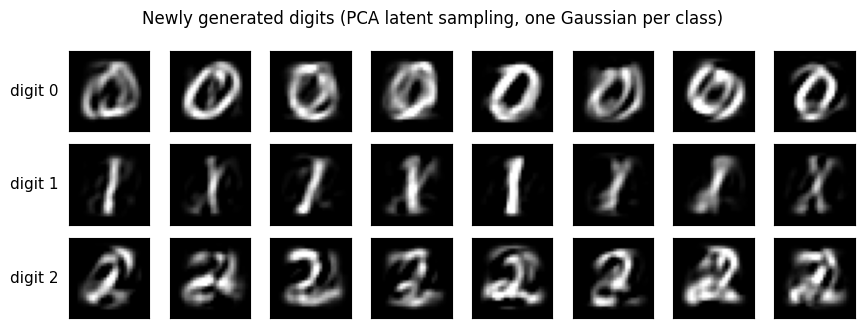

In [5]:
N_PER_DIGIT = 8

fig, axes = plt.subplots(len(DIGITS), N_PER_DIGIT,
                         figsize=(N_PER_DIGIT * 1.1, len(DIGITS) * 1.1))
for row, digit in enumerate(DIGITS):
    mean, cov = per_class[digit]
    latents = sample_latent(mean, cov, n=N_PER_DIGIT, seed=digit)
    imgs = generate(pca, latents, as_images=True)
    for col in range(N_PER_DIGIT):
        ax = axes[row, col]
        ax.imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(f"digit {digit}", fontsize=11, rotation=0,
                            labelpad=25, va="center")
fig.suptitle("Newly generated digits (PCA latent sampling, one Gaussian per class)")
plt.tight_layout()
plt.show()

## Real vs. generated

A quick sanity check: the class means decode to clean "prototype" digits, and
the samples scatter around them.

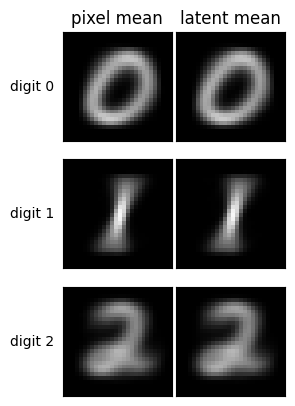

In [6]:
fig, axes = plt.subplots(len(DIGITS), 2, figsize=(3, len(DIGITS) * 1.4))
for row, digit in enumerate(DIGITS):
    real_mean = X[y == digit].mean(axis=0)
    mean, cov = per_class[digit]
    latent_mean_img = generate(pca, mean[None, :], as_images=True)[0]
    axes[row, 0].imshow(as_images(real_mean)[0], cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(latent_mean_img, cmap="gray", vmin=0, vmax=1)
    for col in range(2):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f"digit {digit}", rotation=0, labelpad=22, va="center")
axes[0, 0].set_title("pixel mean")
axes[0, 1].set_title("latent mean")
plt.tight_layout()
plt.show()

## Latent-space interpolation

Walking along a straight line between the latent codes of two real digits and
decoding each step shows how the linear latent space morphs one digit into
another.

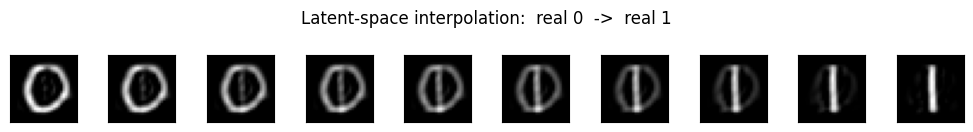

In [7]:
# Pick one real "0" and one real "1" and interpolate between them.
idx_a = np.flatnonzero(y == 0)[0]
idx_b = np.flatnonzero(y == 1)[0]
codes = pca.transform(X[[idx_a, idx_b]])

STEPS = 10
walk = interpolate(pca, codes[0], codes[1], n_steps=STEPS, as_images=True)

fig, axes = plt.subplots(1, STEPS, figsize=(STEPS * 1.0, 1.3))
for col in range(STEPS):
    axes[col].imshow(walk[col], cmap="gray", vmin=0, vmax=1)
    axes[col].set_xticks([]); axes[col].set_yticks([])
fig.suptitle("Latent-space interpolation:  real 0  ->  real 1")
plt.tight_layout()
plt.show()

## What PCA-based generation can and cannot do

**Can:**
- Produce *plausible average-looking* digits cheaply — no iterative training,
  just a fit + a Gaussian sample.
- Capture the dominant, *linear* modes of variation (thickness, slant, overall
  size) that PCA's top components encode.
- Give a smooth, continuous latent space where interpolation stays digit-like.

**Cannot:**
- Capture **nonlinear** structure. Because both the PCA map and the Gaussian are
  linear/quadratic, samples tend toward smooth, slightly blurry "mean" digits
  and miss sharp, localised strokes.
- Model **multimodal** within-class variation well — a single Gaussian assumes
  one blob per class, so distinct writing styles get averaged together.
- Guarantee valid pixels: `inverse_transform` can leave the `[0, 1]` range, so we
  **clip**. Off-manifold samples can look like faint ghosting.

For crisper, more varied digits you'd move to a nonlinear generative model
(e.g. a VAE or GAN); PCA here is the interpretable linear baseline.